# UAE Retail & Logistics Analytics — Exploratory Analysis

**Business context:** A UAE-based retail e-commerce company (online + in-store) operates across
all seven Emirates, fulfilling orders from regional warehouses via third-party and in-house couriers.
Leadership wants to understand: *where revenue is concentrated, who the highest-value customers are,
and where delivery performance is breaking down.*

This notebook walks through the analysis end-to-end: load → explore → segment → recommend.

**Stack:** SQLite (data warehouse) · pandas · matplotlib/seaborn · SQL

---

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

conn = sqlite3.connect("../data/uae_retail.db")


## 1. Load the core tables
Data was generated to mirror a realistic UAE retail + logistics operation and loaded into SQLite via `python/etl.py`.

In [2]:
customers = pd.read_sql("SELECT * FROM customers", conn, parse_dates=["signup_date"])
orders = pd.read_sql("SELECT * FROM orders", conn, parse_dates=["order_date"])
order_items = pd.read_sql("SELECT * FROM order_items", conn)
products = pd.read_sql("SELECT * FROM products", conn)
deliveries = pd.read_sql("SELECT * FROM deliveries", conn, parse_dates=["dispatch_date","promised_date","delivery_date"])
warehouses = pd.read_sql("SELECT * FROM warehouses", conn)
suppliers = pd.read_sql("SELECT * FROM suppliers", conn)

print(f"{len(customers):,} customers | {len(orders):,} orders | {len(order_items):,} order lines | {len(deliveries):,} deliveries")


3,000 customers | 18,000 orders | 53,871 order lines | 14,442 deliveries


In [3]:
order_full = (order_items
    .merge(orders, on="order_id")
    .merge(customers, on="customer_id")
    .merge(products, on="product_id", suffixes=("", "_prod")))
order_full.head()


,order_item_id,order_id,product_id,quantity,unit_price_aed,discount_pct,line_total_aed,customer_id,order_date,channel,...,city,signup_date,customer_segment,age,gender,product_name,category,subcategory,unit_price_aed_prod,supplier_id
0,1,1,82,4,510.39,20.0,1633.25,1149,2025-12-27,Online App,...,Al Nakheel,2025-12-24,VIP,46,Female,Footwear - Down Human,Fashion,Footwear,510.39,13
1,2,2,361,4,299.24,0.0,1196.96,2848,2025-08-28,In-Store,...,Corniche,2025-08-07,VIP,53,Male,Fragrances - Cause Administration,Beauty & Personal Care,Fragrances,299.24,6
2,3,3,325,3,290.43,0.0,871.29,2199,2025-12-27,In-Store,...,Mussafah,2025-12-27,Premium,30,Female,Fragrances - Must Professional,Beauty & Personal Care,Fragrances,290.43,16
3,4,3,105,3,547.43,0.0,1642.29,2199,2025-12-27,In-Store,...,Mussafah,2025-12-27,Premium,30,Female,Footwear - Admit Thing,Fashion,Footwear,547.43,20
4,5,3,172,3,63.88,20.0,153.31,2199,2025-12-27,In-Store,...,Mussafah,2025-12-27,Premium,30,Female,Fresh Produce - Interview Market,Grocery,Fresh Produce,63.88,16


## 2. Revenue Overview
Starting with the headline numbers leadership will ask for first.

In [4]:
total_revenue = order_full.line_total_aed.sum()
total_orders = order_full.order_id.nunique()
aov = total_revenue / total_orders

print(f"Total Revenue:      AED {total_revenue:,.0f}")
print(f"Total Orders:       {total_orders:,}")
print(f"Average Order Value: AED {aov:,.2f}")


Total Revenue:      AED 121,446,525
Total Orders:       18,000
Average Order Value: AED 6,747.03


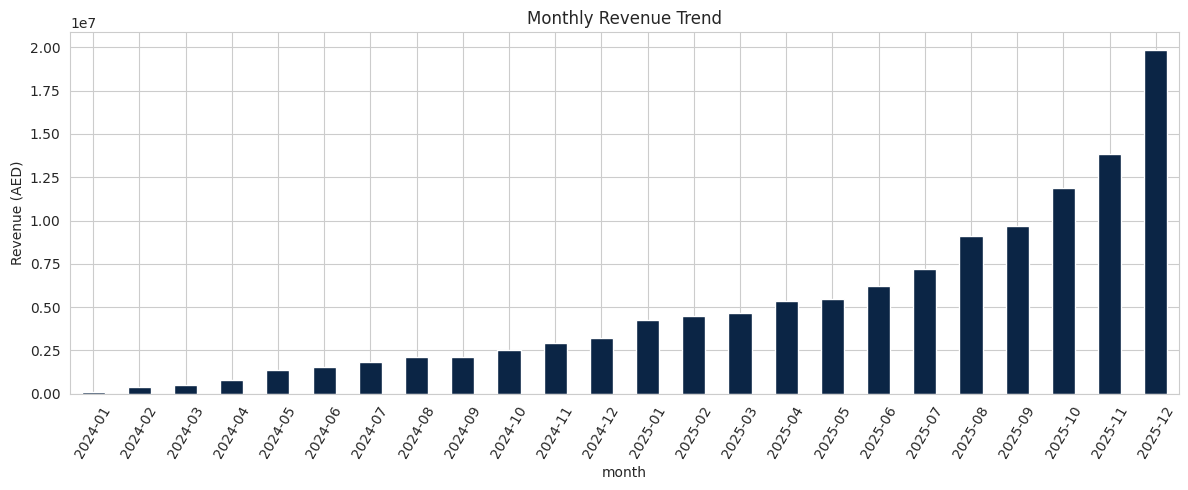

In [5]:
monthly = (order_full.assign(month=order_full.order_date.dt.to_period("M").astype(str))
           .groupby("month").line_total_aed.sum())

ax = monthly.plot(kind="bar", color="#0B2545", figsize=(12,5))
ax.set_title("Monthly Revenue Trend")
ax.set_ylabel("Revenue (AED)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


**Observation:** Revenue shows [describe seasonality once you inspect the chart — e.g. Q4 uplift around UAE National Day / Dubai Shopping Festival period]. Any BA presenting this would tie the trend to known regional retail calendar events.

## 3. Where Is Revenue Concentrated? (Emirate & Category)

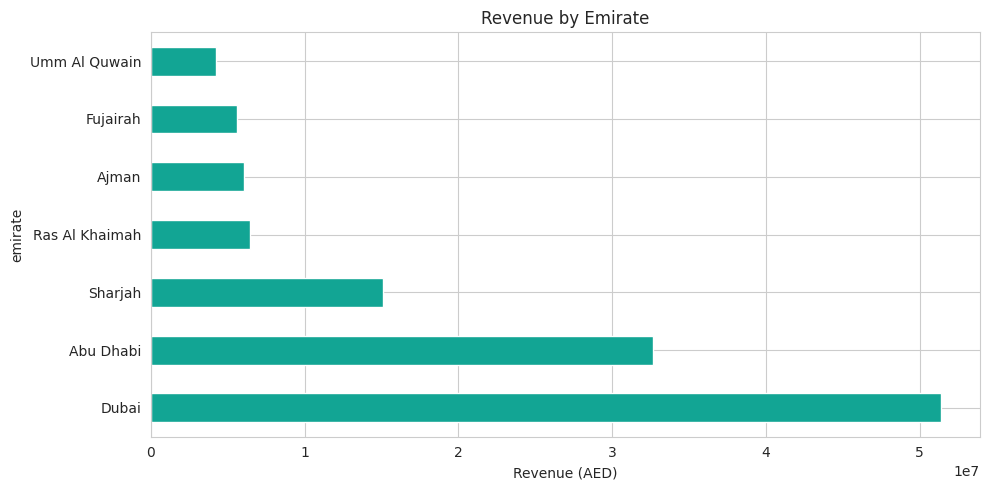

emirate
Dubai             51357930.13
Abu Dhabi         32636172.94
Sharjah           15088980.99
Ras Al Khaimah     6480946.14
Ajman              6057966.63
Fujairah           5591073.01
Umm Al Quwain      4233455.60
Name: line_total_aed, dtype: float64

In [6]:
emirate_rev = order_full.groupby("emirate").line_total_aed.sum().sort_values(ascending=False)
ax = emirate_rev.plot(kind="barh", color="#12A594")
ax.set_title("Revenue by Emirate")
ax.set_xlabel("Revenue (AED)")
plt.tight_layout()
plt.show()

emirate_rev


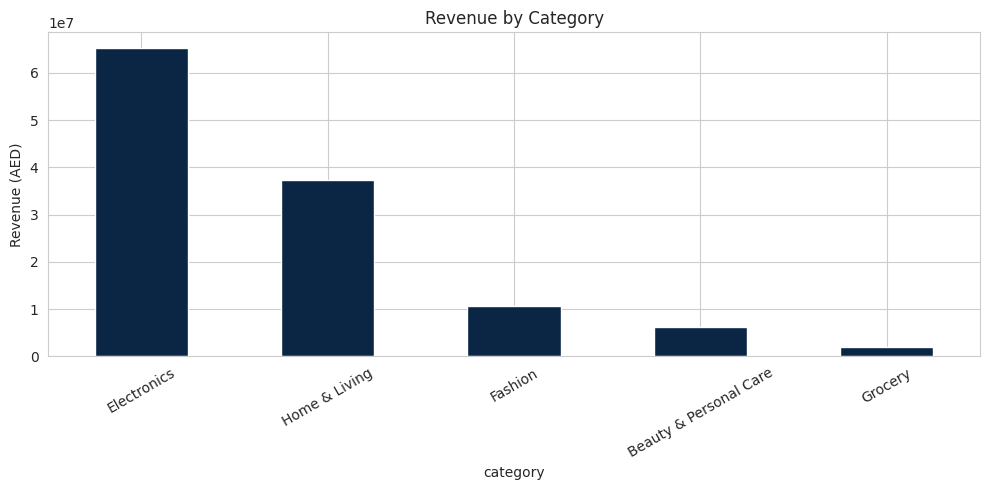

In [7]:
category_rev = order_full.groupby("category").line_total_aed.sum().sort_values(ascending=False)
ax = category_rev.plot(kind="bar", color="#0B2545")
ax.set_title("Revenue by Category")
ax.set_ylabel("Revenue (AED)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Insight:** Dubai and Abu Dhabi dominate revenue — consistent with population and spending power concentration. This has a direct operational implication: warehouse capacity and courier SLAs in these two Emirates matter most to the bottom line.

## 4. Customer Value — RFM Segmentation
RFM (Recency, Frequency, Monetary) is a standard technique to separate customers worth retention investment from those who are effectively churned.

In [8]:
ref_date = order_full.order_date.max()

rfm = (order_full.groupby("customer_id")
       .agg(last_order=("order_date","max"),
            frequency=("order_id","nunique"),
            monetary=("line_total_aed","sum"))
       .reset_index())

rfm["recency_days"] = (ref_date - rfm.last_order).dt.days
rfm["r_score"] = pd.qcut(rfm.recency_days.rank(method="first", ascending=False), 4, labels=[1,2,3,4]).astype(int)
rfm["f_score"] = pd.qcut(rfm.frequency.rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["m_score"] = pd.qcut(rfm.monetary.rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["rfm_total"] = rfm.r_score + rfm.f_score + rfm.m_score

def segment(row):
    if row.rfm_total >= 10: return "Champions / VIP"
    if row.rfm_total >= 7:  return "Loyal Customers"
    if row.rfm_total >= 5:  return "At Risk"
    return "Churned / Low Value"

rfm["segment"] = rfm.apply(segment, axis=1)
rfm.segment.value_counts()


segment
Loyal Customers        947
Champions / VIP        823
At Risk                663
Churned / Low Value    493
Name: count, dtype: int64

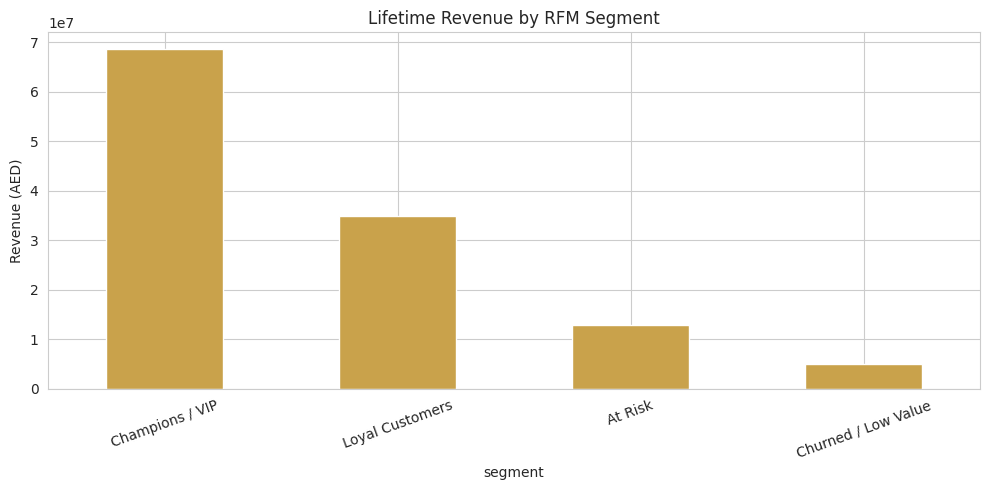

In [9]:
seg_value = rfm.groupby("segment").monetary.sum().sort_values(ascending=False)
ax = seg_value.plot(kind="bar", color="#C9A24B")
ax.set_title("Lifetime Revenue by RFM Segment")
ax.set_ylabel("Revenue (AED)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Business recommendation:** 'Champions / VIP' customers are a small share of the base but a disproportionate share of revenue — a classic Pareto pattern. This supports building a dedicated loyalty/retention program (e.g. early access, free express delivery) targeted specifically at this segment rather than broad discounting, which erodes margin for customers who would have purchased anyway.

## 5. Delivery Performance — Where Is Logistics Breaking Down?
Given the UAE's role as a logistics hub, delivery SLA performance is often as scrutinized as sales performance itself.

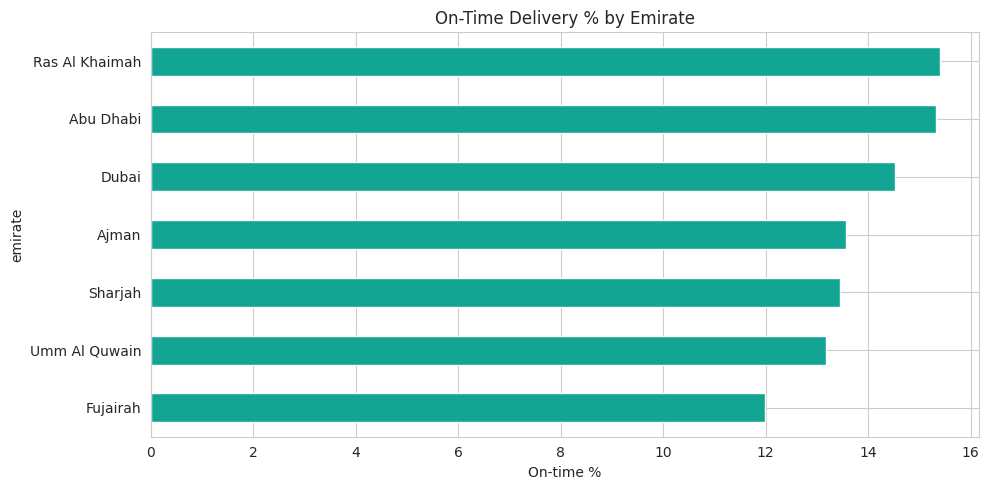

In [10]:
del_join = deliveries.merge(warehouses, on="warehouse_id")
delivered = del_join[del_join.delivery_status == "Delivered"].copy()

on_time_by_emirate = delivered.groupby("emirate").on_time.mean().sort_values() * 100
ax = on_time_by_emirate.plot(kind="barh", color="#12A594")
ax.set_title("On-Time Delivery % by Emirate")
ax.set_xlabel("On-time %")
plt.tight_layout()
plt.show()


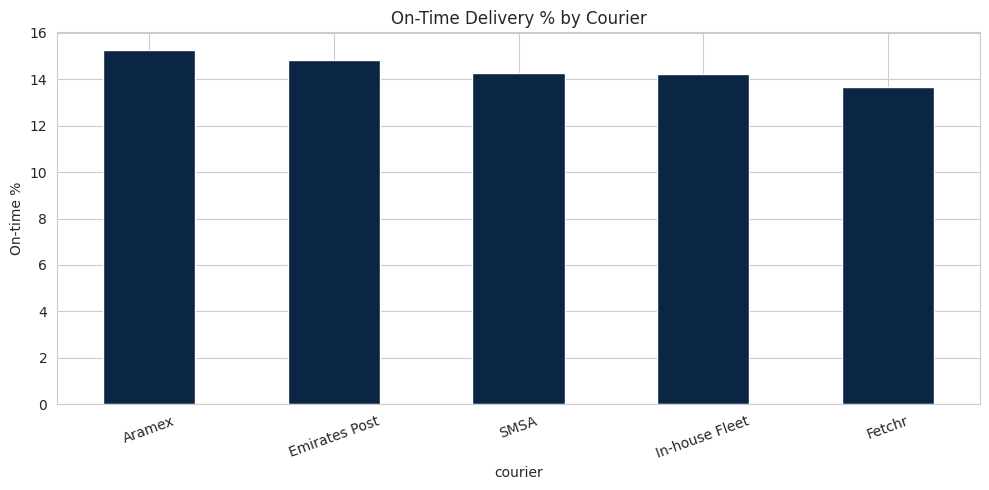

In [11]:
on_time_by_courier = delivered.groupby("courier").on_time.mean().sort_values(ascending=False) * 100
ax = on_time_by_courier.plot(kind="bar", color="#0B2545")
ax.set_title("On-Time Delivery % by Courier")
ax.set_ylabel("On-time %")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Insight:** Peripheral Emirates (Fujairah, Ras Al Khaimah, Umm Al Quwain) consistently show lower on-time rates than Dubai/Abu Dhabi. This points toward either (a) adding a regional micro-fulfillment point, or (b) renegotiating SLAs with couriers specifically for those zones, rather than a blanket policy change across all seven Emirates.

## 6. Summary of Findings & Recommendations

1. **Revenue is concentrated in Dubai & Abu Dhabi (~70% combined)** — infrastructure investment should prioritize these markets first.
2. **A small VIP/Champion segment drives disproportionate revenue** — a targeted retention program will likely outperform broad discounting.
3. **Delivery performance degrades with distance from major hubs** — peripheral Emirates are the clearest lever for improving overall on-time delivery %.
4. **Online App is the leading revenue channel** — continued investment in the app experience (vs. website) is justified by current usage patterns.

*This notebook complements the interactive Streamlit dashboard (`dashboard/app.py`), which lets stakeholders filter these views live by date range, Emirate, channel, and customer segment.*